## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Султанбекова Орнелла ИАД-9

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


In [14]:
data[data['Sex'] == '.']

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
41,Gentoo,Biscoe,Yes,0,44.5,15.7,217.0,4875.0,.,8.04111,-26.18444


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [4]:
data.info()
# видим, что все занчения float кроме этих: Species, Island, Clutch Completion, Sex
# они object -> категориальные
# однако Species - это целевая перемнная

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Clutch Completion    344 non-null    object 
 3   Date Egg             344 non-null    int64  
 4   Culmen Length (mm)   342 non-null    float64
 5   Culmen Depth (mm)    342 non-null    float64
 6   Flipper Length (mm)  342 non-null    float64
 7   Body Mass (g)        342 non-null    float64
 8   Sex                  334 non-null    object 
 9   Delta 15 N (o/oo)    330 non-null    float64
 10  Delta 13 C (o/oo)    331 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 29.7+ KB


In [ ]:
data = data.dropna()
categorical_col = ['Island', 'Clutch Completion', 'Sex']

# мною была замечена странная строка, где Sex = '.'
# решила, что ее тоже следует удалить из статистики
ind = data[data['Sex'] == '.'].index
data = data.drop(ind)

data = pd.get_dummies(data, columns=categorical_col, drop_first=False)

Использую One-Hot Encoder с помощью pd.get_dummies

Данный тип кодирования, основывается на создании бинарных признаков, которые показывают принадлежность к уникальному значению.

Изначально столбцов: 11
У меня три категориальных столбца, которые имеют уникальные занчения: для Island - 2, Clutch Completion - 3, Sex - 2. Тогда новых - 7.

В итоге имеем: 18
Думаю, что это несильное увелечение нашей таблицы, поэтому данный метод кодирования тут уместен.

Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [22]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data['Species_enc'] = enc.fit_transform(data[['Species']]).astype(int)

X = data.drop(columns=['Species', 'Species_enc'])
Y = data['Species_enc']

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [23]:
from sklearn.model_selection import train_test_split

np.random.seed(42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y, random_state=42)

 Функция stratify автоматически делит данные так, чтобы в каждом подмножестве доли классов были одинаковыми. То есть это помогает грамотно балансировать между "хорошими" и "плохими" данными (сохраняет пропорции), тем самым обучая модель лучшим образом и предотвращая переобучение.


**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X_train_knn = X_train[['Flipper Length (mm)', 'Body Mass (g)']]
X_test_knn = X_test[['Flipper Length (mm)', 'Body Mass (g)']]

scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_knn)
X_test_knn = scaler.transform(X_test_knn)

k_val = [1, 3, 5, 10, 15, 25]
res = []
clas = []
for k in k_val:
  knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
  knn.fit(X_train_knn, Y_train)
  clas.append(knn)

  train_acc = accuracy_score(Y_train, knn.predict(X_train_knn))
  test_acc = accuracy_score(Y_test, knn.predict(X_test_knn))

  res.append({
        'k': k,
        'train_acc': train_acc,
        'test_acc': test_acc
    })
res = pd.DataFrame(res)
print(res)

    k  train_acc  test_acc
0   1   0.969027  0.755102
1   3   0.853982  0.755102
2   5   0.831858  0.775510
3  10   0.827434  0.775510
4  15   0.814159  0.755102
5  25   0.796460  0.836735


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [25]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [26]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

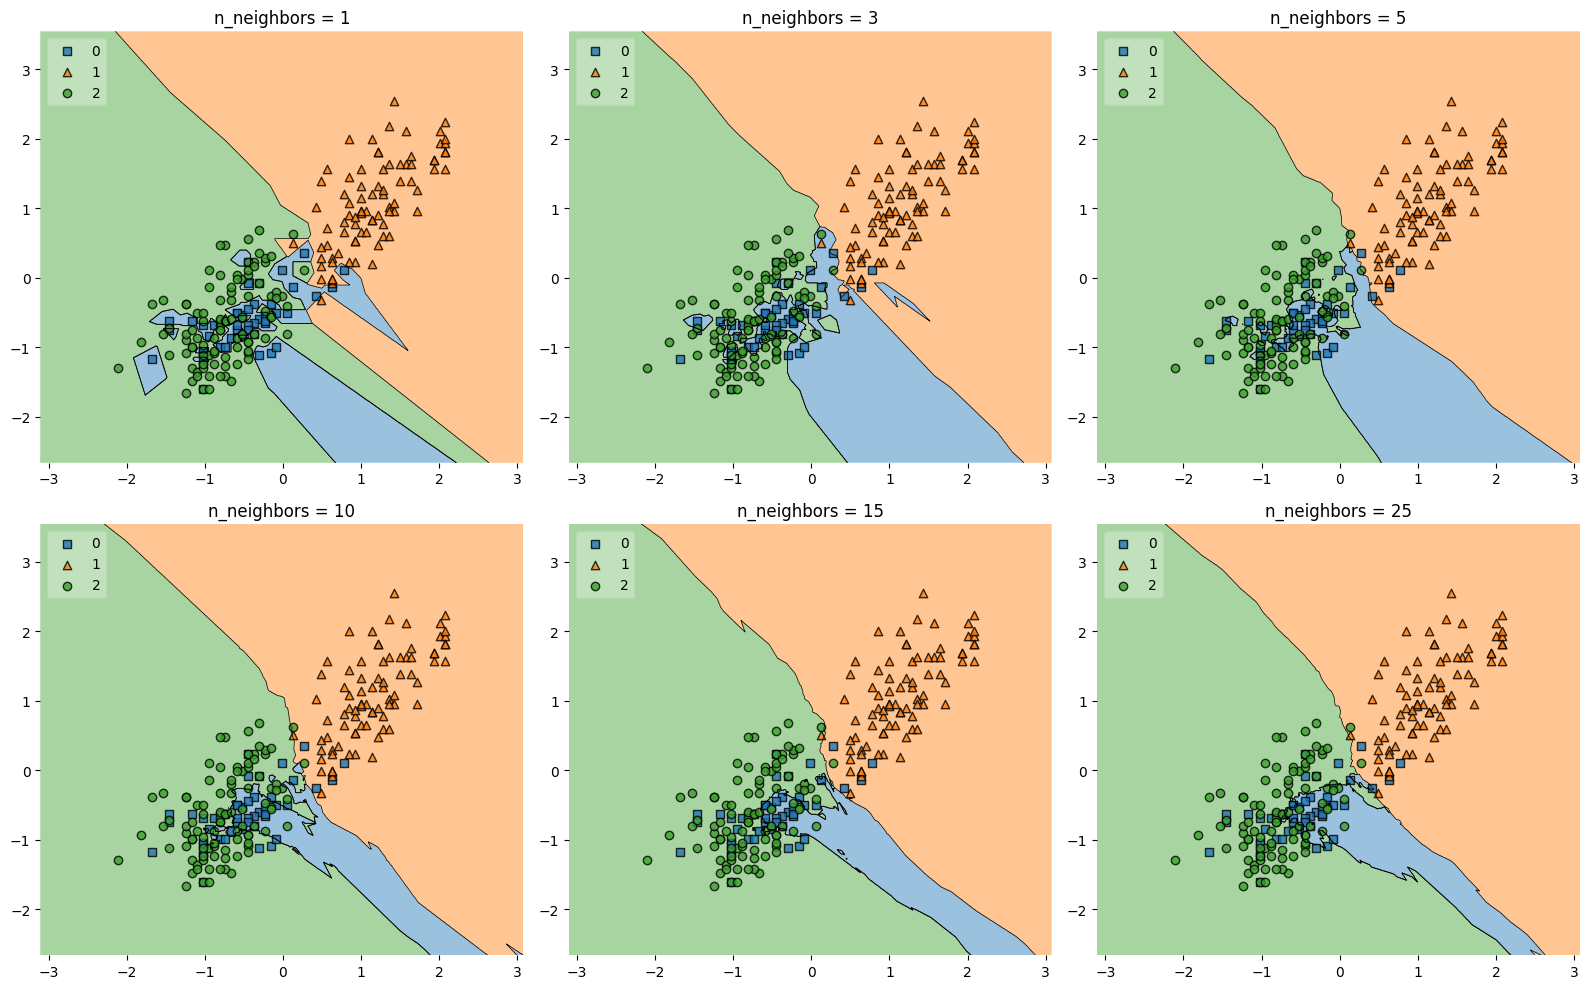

In [27]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools

gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(16, 10))

labels = [f'n_neighbors = {k}' for k in k_val]
for clf, lab, grd in zip(clas, labels, itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    plot_decision_regions(X=np.array(X_train_knn), y=np.array(Y_train), clf=clf, legend=2)
    plt.title(lab)

plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Наилучшее кол-во соседей k=10, так как accuracy при таком k довольно высокое и график показывает четкое разделение пространства на три класса (то есть решающая поверхность становиться гладкой и стабильной).
При k = 1, k = 3 заметно переобучение, так как разделениеешающая поверхность очень рваная и острая, так как она пытается подстроиться под каждую отдельную точку.
При k = 25 - это скорее аномалии, так как это довольно большое значение для данного гиперпараметра, более того, на грфике видно, что решающая поверхность становиться рваной.

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

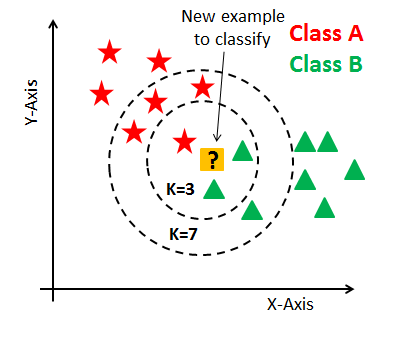

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [28]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
      if k < 1:
        raise ValueError("k должно быть больше 1")

      self.k = k

    def fit(self, X, y):
      self.X_train = np.array(X)
      self.y_train = np.array(y)

      if self.X_train.shape[0] != self.y_train.shape[0]:
          raise ValueError("Количество образцов в X и y должно совпадать")

    def predict(self, X):
      predictions = []
      for x in X:
        d = [self.count_distance(x, x_train) for x_train in self.X_train]
        k_nearest_indices = np.argsort(d)[:self.k]
        k_nearest_labels = self.y_train[k_nearest_indices]
        ans = Counter(k_nearest_labels).most_common(1)[0][0]
        predictions.append(ans)
      return np.array(predictions)

    def count_distance(self, x, y):
      return np.linalg.norm(x - y)

In [29]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [30]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [31]:
best_k = None
best_score = 0

print("Свой KNN:")
for k in k_val:
    knn_custom = KNN(k=k)
    knn_custom.fit(X_train_knn, Y_train)
    y_pred_custom = knn_custom.predict(X_test_knn)
    acc = accuracy_score(Y_test, y_pred_custom)
    print(f"k={k}, Test Accuracy: {acc:.4f}")
    if acc > best_score:
        best_score = acc
        best_k = k

print(f"\nЛучшее k: {best_k} с точностью {best_score:.4f} на test.")

Свой KNN:
k=1, Test Accuracy: 0.7653
k=3, Test Accuracy: 0.7449
k=5, Test Accuracy: 0.7755
k=10, Test Accuracy: 0.7857
k=15, Test Accuracy: 0.7653
k=25, Test Accuracy: 0.8367

Лучшее k: 25 с точностью 0.8367 на test.


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [46]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [35]:
data.isnull().sum() # нет пропусков

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [47]:
data = data.drop("Unnamed: 0", axis=1)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [42]:
corr_mtx = data.corr(numeric_only=True)
corr_mtx

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


Наибольшую корреляцию с целевой перемнной (ценой) составляет поле carat (0.92). Следовательно, чем больше значени карата, тем дороже.

Также размеры (x, y, z), так как чем больше алмаз, тем он дороже.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [48]:
data = pd.get_dummies(data, columns=['cut', 'color', 'clarity'], drop_first=True)
data

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [49]:
from sklearn.model_selection import train_test_split

X = data.drop('price', axis=1)
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Процедура масштабирования признаков очень важна, так как позволяет выравнивать данных, то есть с различными диапазонами приводить к единицами измерения (к единому масштабу). Такое преобразование позволяет избежать влияния признаков с большими значениями на модель, ускоряет сходимость градиентного спуска и улучшает точность моделей, основанных на расстояниях.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train_sc, y_train)

train_mse_linear_regr = mean_squared_error(y_train, model.predict(X_train_sc))
test_mse_linear_regr = mean_squared_error(y_test, model.predict(X_test_sc))

print(f"MSE for train: {train_mse_linear_regr:.4f}")
print(f"MSE for test: {test_mse_linear_regr:.4f}")

MSE for train: 1290541.9147
MSE for test: 1244765.4357


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [53]:
coef = model.coef_
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': coef
})
coef_df

,feature,coefficient
0,carat,5338.615671
1,depth,-90.173817
2,table,-60.332280
3,x,-1100.418850
4,y,-6.458917
5,z,-34.258945
6,cut_Good,170.602933
7,cut_Ideal,414.369515
8,cut_Premium,339.239204
9,cut_Very Good,310.654256


Большие занчения по модулю имеют колонки carat и x.
Это может указывать на мультиколлинеарность (то есть признаки сильно коррелированы между собой)

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [57]:
from sklearn.linear_model import Lasso, Ridge

a = 10

ridge = Ridge(alpha=a)
ridge.fit(X_train_sc, y_train)

print("Ridge")
c_r = ridge.coef_
coef_ridge = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': c_r
})

mse_train = mean_squared_error(y_train, ridge.predict(X_train_sc))
mse_test = mean_squared_error(y_test, ridge.predict(X_test_sc))

print(f'Ridge: MSE на тренировачной выборке: {mse_train:.4f}, на тестовой: {mse_test:.4f}')

Ridge
Ridge: MSE на тренировачной выборке: 1290671.4987, на тестовой: 1244573.4008


In [59]:
coef_ridge

,feature,coefficient
0,carat,5299.360461
1,depth,-88.383025
2,table,-60.576796
3,x,-1057.321756
4,y,-9.148025
5,z,-37.568864
6,cut_Good,171.203364
7,cut_Ideal,415.480169
8,cut_Premium,340.215934
9,cut_Very Good,312.016066


In [56]:
lasso = Lasso(alpha=a)
lasso.fit(X_train_sc, y_train)

print("Lasso")
c_l = lasso.coef_
coef_lasso = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': c_l
})

mse_train = mean_squared_error(y_train, lasso.predict(X_train_sc))
mse_test = mean_squared_error(y_test, lasso.predict(X_test_sc))

print(f'Lasso: MSE на тренировачной выборке: {mse_train:.4f}, на тестовой: {mse_test:.4f}')

Lasso
Lasso: MSE на тренировачной выборке: 1351084.3270, на тестовой: 1293860.3257


In [58]:
coef_lasso

,feature,coefficient
0,carat,4831.596261
1,depth,-96.516853
2,table,-71.937944
3,x,-651.185193
4,y,-0.000000
5,z,-28.494759
6,cut_Good,46.135965
7,cut_Ideal,206.837676
8,cut_Premium,151.391271
9,cut_Very Good,139.241494


Видно, что коэффициенты уменьшились как и при Ridge, так и при Lasso.
Однако, при Lasso некоторые коэффциенты вообще обратились в ноль.

Но при этом видно, что коэффициенты не так сильно уменьшились, следовательно, большой проблемы с мультиколлинеарностью не было.

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

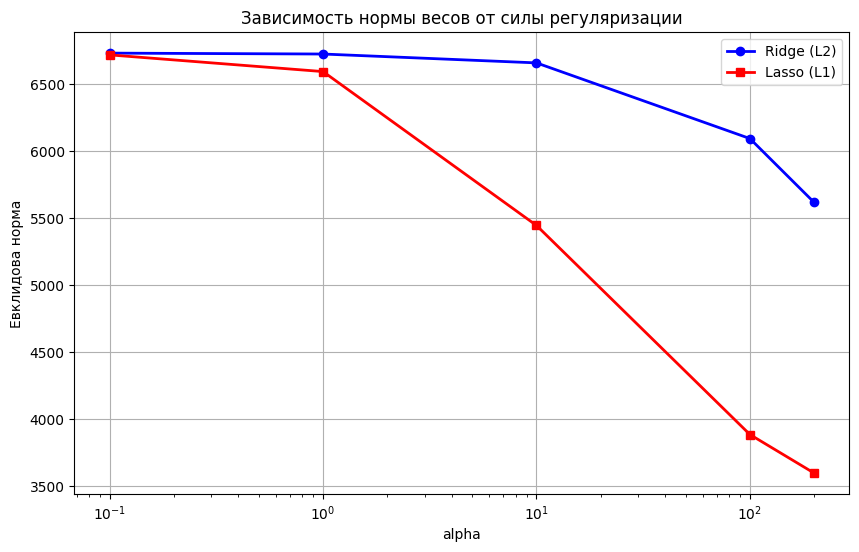

In [60]:
alphas = [0.1, 1, 10, 100, 200]

ridge_res, lasso_res = [], []
for a in alphas:
  ridge = Ridge(alpha=a)
  ridge.fit(X_train_sc, y_train)
  ridge_res.append(np.linalg.norm(ridge.coef_))

  lasso = Lasso(alpha=a)
  lasso.fit(X_train_sc, y_train)
  lasso_res.append(np.linalg.norm(lasso.coef_))

plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_res, 'b-o', label='Ridge (L2)', linewidth=2)
plt.plot(alphas, lasso_res, 'r-s', label='Lasso (L1)', linewidth=2)
plt.xlabel('alpha')
plt.ylabel('Евклидова норма')
plt.xscale('log')
plt.title('Зависимость нормы весов от силы регуляризации')
plt.legend()
plt.grid(True)
plt.show()

По графику хорошо видно, что Lasso (L1) сильнее снижает норму при одинаковом alpha (a). Происходит это из-за того, что L1 "обнуляет" веса, а L2 только "прижимает" к нулю.

А так как Lasso сильнее снижает норму (например,при увеличении alpha (a) часть весов точно равна 0), то его чаще и используют.  

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [63]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-1, 3, 1000)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_sc, y_train)
mean_mse = lasso_cv.mse_path_.mean(axis=1)
ind = np.argmin(mean_mse)
ans = lasso_cv.alphas_[ind]
print(f"Наилучшее значение alpha {ans}")

Наилучшее значение alpha 0.4174655289253137


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [64]:
new_lasso = Lasso(alpha=ans)
new_lasso.fit(X_train_sc, y_train)
coef_lasso = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': new_lasso.coef_
})
coef_lasso

,feature,coefficient
0,carat,5317.376338
1,depth,-90.402854
2,table,-60.803942
3,x,-1083.072018
4,y,-4.527493
5,z,-34.178898
6,cut_Good,165.436488
7,cut_Ideal,405.773325
8,cut_Premium,331.471213
9,cut_Very Good,303.540440


Мне кажется, что информативными полями считаются: carat , x , clarity. Так как они указывают на основные характеристики бриллианта, от которых зависит цена (вес, размер, чистота).

А неинформативные - это depth и table, так как почти не имеют влияния на цену.


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [65]:
test_mse_lasso = mean_squared_error(y_test, new_lasso.predict(X_test_sc))
print(f"MSE for Linear Regression: {test_mse_linear_regr}")
print(f"MSE for New Lasso: {test_mse_lasso}")

MSE for Linear Regression: 1244765.4357158695
MSE for New Lasso: 1244273.5246812531


По-моему мнению, лучше использовать lasso-регресию, так как она с регуляризатором, поэтому может понизить MSE, а также вообще занулить незначительные коэффициенты.